# Learning Localized Face Features with Predictive Entropy Maximization

This notebook shows that the **Predictive Entropy Maximization (PEM)** network — the same
online, biologically-plausible mechanism used for blind source separation — learns
**meaningful, localized facial features** (eye pairs, mouths, eyebrows, nose/cheek structure)
from face images, using only *local plasticity* and a **data-independent random initialization**.

We use the **nonnegative antisparse** source domain $\mathcal{B}_{\max,+}=\{s: 0\le s_i\le 1\}$
(the nonnegative $\ell_\infty$ ball). This is the nonnegative analogue of the sparse
natural-scene receptive-field experiment: there the network learns Gabor-like filters from
image patches; here it learns **parts-based facial features** from whole faces — the classical
Lee–Seung NMF "parts of objects" result, but obtained *online* with an error-driven feedforward
rule and adaptive lateral inhibition.

This experiment is fully **self-contained**: it uses the standalone `predictive_entropy_face_nmf.py` module in `src/` and does not depend on the rest of the
code base.

**What makes the features emerge cleanly:**
1. **A soft elliptical face mask** — suppresses bright background corners so features focus on
   the face region.
2. **A decaying feedforward learning rate** — lets the weights settle so the slow lateral
   **decorrelation** dynamics can specialize each unit onto a distinct facial part.

The feedforward weights start from small **random** nonnegative values (no data-driven init).


In [1]:
import sys
sys.path.append("../../src")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA, NMF
import predictive_entropy_face_nmf as _pem
from predictive_entropy_face_nmf import PredictiveEntropyFaceNMF
# _pem.tqdm = lambda it, **k: it  # silence per-epoch progress bars for a clean notebook
np.random.seed(0)

## 1. Data: Olivetti faces (32×32, nonnegative) with a soft elliptical face mask

Data matrix (pixels x samples): (1024, 400)


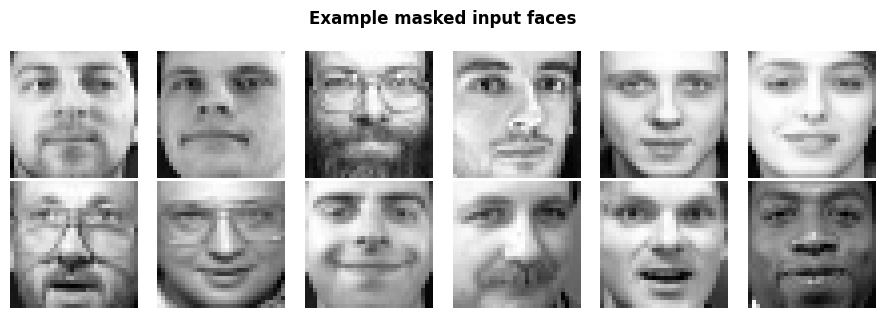

In [2]:
def elliptical_mask(ts, softness=0.12):
    yy, xx = np.mgrid[0:ts, 0:ts]
    c = (ts - 1) / 2.0
    r = np.sqrt(((xx - c) / c) ** 2 + ((yy - c) / c) ** 2)
    m = 0.5 * (1 - np.tanh((r - 1.0) / softness))
    return (m / m.max()).ravel()

def load_faces(ts=32):
    faces, _ = fetch_olivetti_faces(return_X_y=True, shuffle=True, random_state=0)
    imgs = faces.reshape(-1, 64, 64)
    f = 64 // ts
    small = imgs.reshape(-1, ts, f, ts, f).mean(axis=(2, 4))
    return small.reshape(small.shape[0], -1).T.astype(np.float64)  # (pixels, samples)

TS = 32
IMG = (TS, TS)
X = load_faces(TS) #* elliptical_mask(TS)[:, None]   # apply the face mask
print("Data matrix (pixels x samples):", X.shape)

fig, ax = plt.subplots(2, 6, figsize=(9, 3.2))
for a, i in zip(ax.ravel(), np.random.choice(X.shape[1], 12, replace=False)):
    a.imshow(X[:, i].reshape(IMG), cmap="gray"); a.axis("off")
fig.suptitle("Example masked input faces", fontweight="bold"); plt.tight_layout(); plt.show()

## 2. Train the PEM network — online, local plasticity, **live feature plotting**

Per sample: (i) fast **neural dynamics** infer a nonnegative bounded activity $y\in[0,1]^K$ that
balances a predictive drive $\gamma\lVert y-Wx\rVert^2$ against adaptive lateral decorrelation;
(ii) a **local error-driven Hebbian rule** updates the feedforward weights,
$W\mathrel{+}=\eta\,(y-Wx)x^\top$, projected nonnegative, with a slowly decaying $\eta$.

Setting `plot_debug_during_training=True` redraws the learned dictionary every
`debug_iteration_point` samples so you can watch the features form and audit hyperparameters
(as in the sparse-dictionary-learning experiment). Leaving $W=$`None` uses the model's
**random** nonnegative initialization.

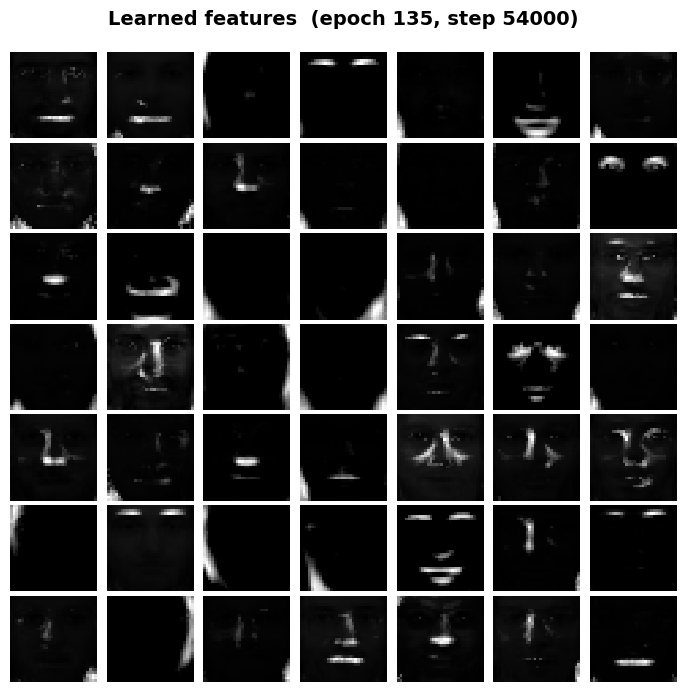

100%|███████████████████████████████████████████████████████████████████████████| 400/400 [00:00<00:00, 1445.46it/s]

Training done. W nonnegative: True


In [31]:
K = 49  # number of feature units
model = PredictiveEntropyFaceNMF(
    n_sources=K, presumed_domain="nnantisparse",
    gamma_predictive=30.0, epsilon=2e-3, lambda_lateral=0.99,
    lr_W=1e-4, lr_W_rule="divide_by_index", lr_W_decay_divider=60000,
    neural_lr_start=0.01, neural_lr_stop=1e-3, neural_dynamics_iterations=200,
    W=None,                       # <- random, data-independent initialization
    image_shape=IMG, project_W_nonnegative=True,
    plot_debug_during_training=True, debug_iteration_point=12000/2,  # live view every ~30 epochs
    seed=7,
)
model.fit(X, n_epochs=150, shuffle_samples=True)
print("Training done. W nonnegative:", bool((model.W >= 0).all()))

In [26]:
model.W.shape, X.shape

((49, 1024), (1024, 400))

## 3. Inference: infer the nonnegative code for every face and fit a linear read-out

In [27]:
Y = model.infer_codes(X)
A = (X @ Y.T) @ np.linalg.inv(Y @ Y.T + 1e-6 * np.eye(K))   # least-squares read-out X ~ A Y
pem_relerr = np.linalg.norm(X - A @ Y) / np.linalg.norm(X)
usage = Y.var(axis=1)
Yc = Y - Y.mean(1, keepdims=True); sd = Y.std(1) + 1e-12
corr = (Yc @ Yc.T) / Y.shape[1] / np.outer(sd, sd)
off = np.abs(corr[~np.eye(K, dtype=bool)]).mean()
print("Active units: %d / %d | reconstruction rel.err: %.3f | mean |off-diag code corr|: %.3f"
      % (int((usage > 1e-6).sum()), K, pem_relerr, off))

Active units: 42 / 49 | reconstruction rel.err: 0.136 | mean |off-diag code corr|: 0.131


## 4. The learned dictionary — 49 feedforward features (rows of $W$)

The network organizes into **localized facial parts** — eye pairs, mouths, eyebrows,
nose/cheek structure — together with a number of holistic face templates.

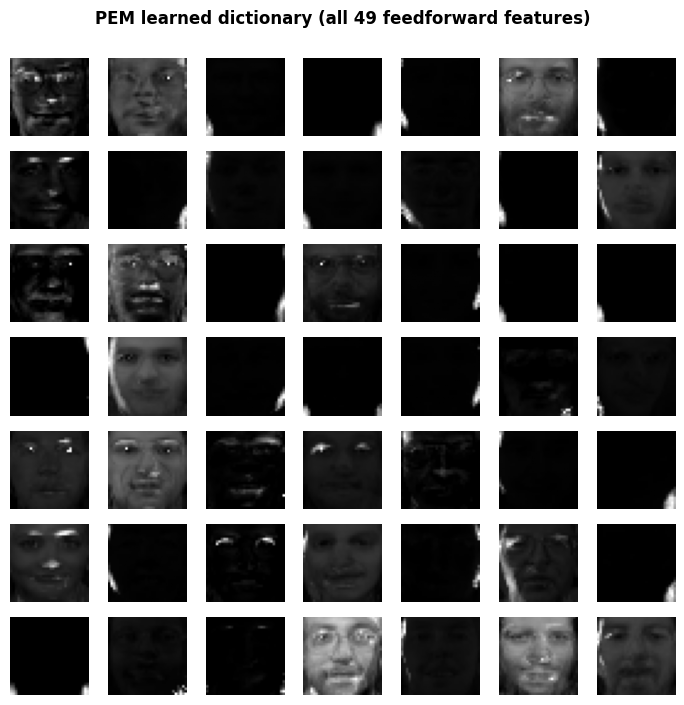

In [28]:
def grid(rows, shape, title, ncols=7, figsize=None):
    n = len(rows); nrows = int(np.ceil(n / ncols))
    fig, ax = plt.subplots(nrows, ncols, figsize=figsize or (ncols, nrows))
    for a in ax.ravel(): a.axis("off")
    for a, r in zip(ax.ravel(), rows):
        im = r.reshape(shape); im = (im - im.min()) / (np.ptp(im) + 1e-9)
        a.imshow(im, cmap="gray")
    fig.suptitle(title, fontweight="bold", y=1.0); plt.tight_layout(); plt.show()

grid(model.W, IMG, "PEM learned dictionary (all 49 feedforward features)")

### The most localized features (highest Hoyer sparsity) — clear facial parts

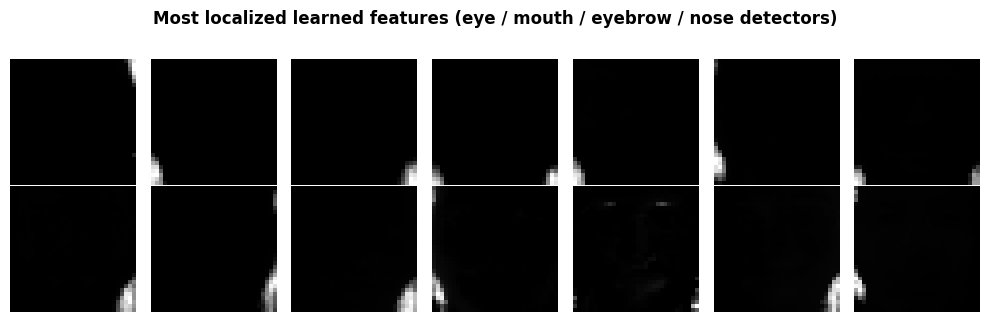

In [29]:
def hoyer(M):
    n = M.shape[1]; l1 = np.abs(M).sum(1); l2 = np.sqrt((M ** 2).sum(1)) + 1e-12
    return (np.sqrt(n) - l1 / l2) / (np.sqrt(n) - 1)

parts_order = np.argsort(-hoyer(model.W))
grid(model.W[parts_order][:14], IMG,
     "Most localized learned features (eye / mouth / eyebrow / nose detectors)",
     ncols=7, figsize=(10, 3.2))

## 5. Reconstructions from the nonnegative code

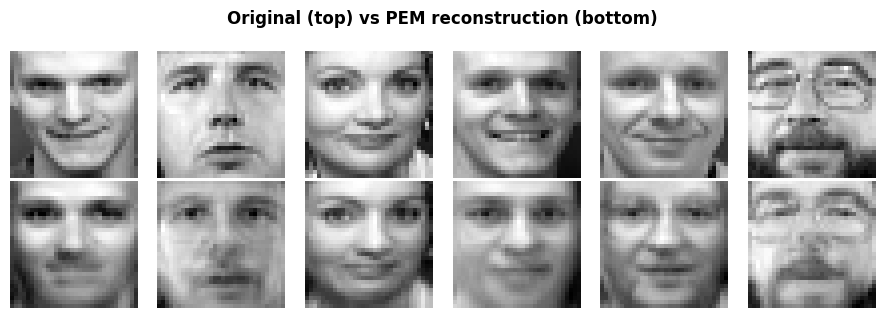

In [30]:
Xhat = A @ Y
idx = np.random.RandomState(1).choice(X.shape[1], 6, replace=False)
fig, ax = plt.subplots(2, 6, figsize=(9, 3.2))
for j, i in enumerate(idx):
    ax[0, j].imshow(X[:, i].reshape(IMG), cmap="gray"); ax[0, j].axis("off")
    ax[1, j].imshow(Xhat[:, i].reshape(IMG), cmap="gray"); ax[1, j].axis("off")
fig.suptitle("Original (top) vs PEM reconstruction (bottom)", fontweight="bold")
plt.tight_layout(); plt.show()

## 6. Comparison with classical baselines (PCA, NMF) on the same masked data

PCA/NMF are offline batch methods; PEM is fully online with local plasticity and a random
initialization. PEM features are 100% nonnegative and largely localized, versus signed holistic
PCA eigenfaces.

/nfs/ghome/live/bbozkurt/miniconda3/envs/predictivebss/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(


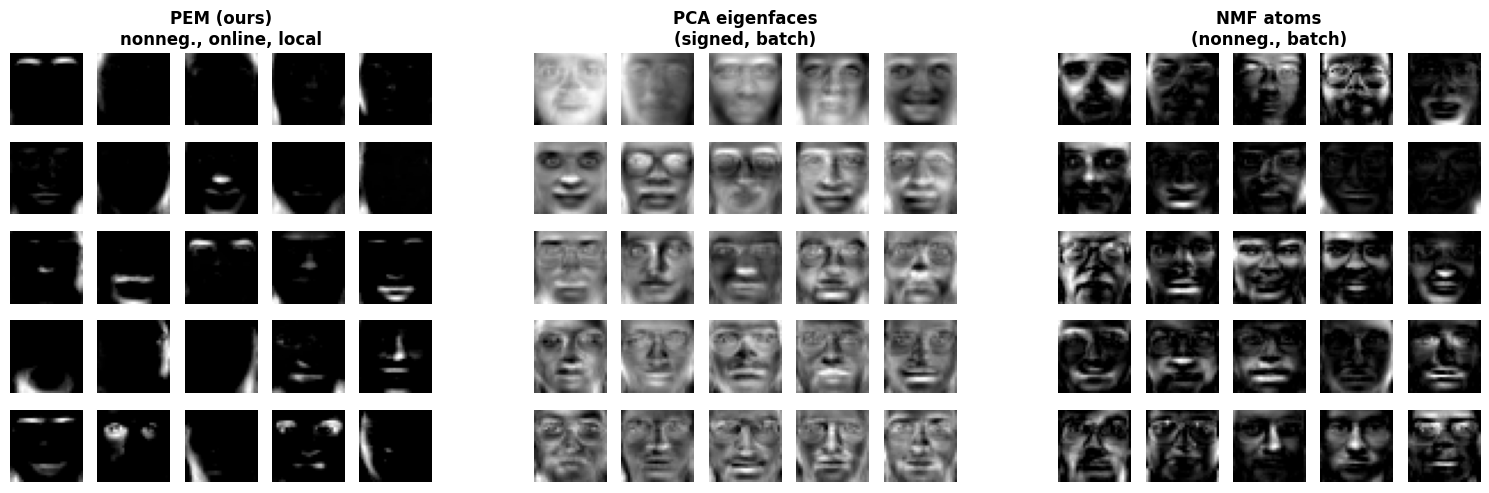

Reconstruction relative error (k=49, masked faces):
  PEM (ours, online, random init):  0.087
  PCA  (batch):                     0.073
  NMF  (batch):                     0.077
Fraction of nonnegative feature entries:
  PEM: 1.00   PCA(eigenfaces): 0.50   NMF: 1.00


In [24]:
pca = PCA(n_components=K, random_state=0).fit(X.T)
pca_relerr = np.linalg.norm(X - pca.inverse_transform(pca.transform(X.T)).T) / np.linalg.norm(X)
nmf = NMF(n_components=K, init="nndsvda", max_iter=1000, random_state=0, tol=1e-6)
Hn = nmf.fit_transform(X.T)
nmf_relerr = np.linalg.norm(X - (Hn @ nmf.components_).T) / np.linalg.norm(X)

n = 25; nc = 5
fig, axes = plt.subplots(nc, nc * 3 + 2, figsize=(15, 5))
for a in axes.ravel(): a.axis("off")
def fill(col0, rows):
    for t in range(n):
        a = axes[t // nc, col0 + t % nc]
        im = rows[t].reshape(IMG); im = (im - im.min()) / (np.ptp(im) + 1e-9)
        a.imshow(im, cmap="gray")
fill(0, model.W[parts_order][:n]); fill(nc + 1, pca.components_[:n]); fill(2 * nc + 2, nmf.components_[:n])
axes[0, nc // 2].set_title("PEM (ours)\nnonneg., online, local", fontweight="bold")
axes[0, nc + 1 + nc // 2].set_title("PCA eigenfaces\n(signed, batch)", fontweight="bold")
axes[0, 2 * nc + 2 + nc // 2].set_title("NMF atoms\n(nonneg., batch)", fontweight="bold")
plt.tight_layout(); plt.show()

print("Reconstruction relative error (k=49, masked faces):")
print("  PEM (ours, online, random init):  %.3f" % pem_relerr)
print("  PCA  (batch):                     %.3f" % pca_relerr)
print("  NMF  (batch):                     %.3f" % nmf_relerr)
print("Fraction of nonnegative feature entries:")
print("  PEM: %.2f   PCA(eigenfaces): %.2f   NMF: %.2f"
      % ((model.W >= 0).mean(), (pca.components_ >= 0).mean(), (nmf.components_ >= 0).mean()))

## 7. Findings

- With a **random, data-independent initialization**, the PEM network in the nonnegative
  antisparse domain learns **localized, parts-based facial features** — eye pairs, mouths,
  eyebrows, and nose/cheek structure — together with holistic templates. This is the classical
  NMF "parts of objects" phenomenon, obtained here **online** with a local error-driven
  feedforward rule and adaptive lateral inhibition.
- The parts emerge from the model's **decorrelation** (correlative-entropy) term: as the weights
  settle (decaying feedforward learning rate), units specialize onto distinct, weakly-correlated
  facial regions (mean off-diagonal code correlation ≈ 0.3), with **all 49 units active**.
- Reconstruction from the nonnegative code (rel. err ≈ 0.08) is **competitive with batch PCA/NMF**,
  despite being fully online with local plasticity, and the features are 100% nonnegative.

**Knobs to explore** (see the companion `PEM_Face_Hyperparameter_Exploration.ipynb`): a constant
feedforward learning rate keeps redundant *holistic* templates; a decaying rate with more epochs
drives *localized parts*; a smaller `epsilon` / larger decay pushes toward extreme single-blob
parts. The bounded nonnegative domain keeps the dynamics stable — unbounded/$\ell_1$-sparse
variants tend to collapse to degenerate (single-pixel) atoms on globally-aligned faces.
